# Iterative Solvers for Linear Systems

## Jacobi & Gauss–Seidel Methods for $Ax = b$

This notebook implements and compares the two classical iterative
methods for solving a system of linear equations $Ax = b$.

| Method | Update rule | Key property |
|--------|-------------|:------------:|
| **Jacobi** | Uses only values from the **previous** iteration | Easy to parallelise |
| **Gauss–Seidel** | Uses **new** values as soon as they are available | Faster convergence |

Both methods converge when the matrix $A$ is **strictly diagonally dominant**:

$$
|a_{ii}| > \sum_{j \neq i} |a_{ij}| \qquad \text{for all } i
$$

---

## 1 — Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "figure.dpi": 120,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.size": 11,
})

## 2 — The Two Methods

### 2.1 Jacobi Iteration

Each component $x_i$ is updated using **only** values from the
previous iteration $\mathbf{x}^{(k)}$:

$$
x_i^{(k+1)} = \frac{1}{a_{ii}} \left( b_i - \sum_{j \neq i} a_{ij}\, x_j^{(k)} \right)
$$

### 2.2 Gauss–Seidel Iteration

Each component uses the **most recent** values — those already
updated in the current sweep ($j < i$) and old values ($j > i$):

$$
x_i^{(k+1)} = \frac{1}{a_{ii}} \left( b_i
  - \sum_{j < i} a_{ij}\, x_j^{\color{red}(k+1)}
  - \sum_{j > i} a_{ij}\, x_j^{(k)} \right)
$$

The only difference is highlighted in red: Gauss–Seidel
uses the new values *immediately*.

In [2]:
def relative_residual(A, b, x):
    """Compute ||b - Ax|| / ||b||."""
    r = b - A @ x
    norm_b = np.linalg.norm(b)
    return np.linalg.norm(r) / norm_b if norm_b > 0 else np.linalg.norm(r)


def jacobi(A, b, x0, max_iter=50, tol=1e-10):
    """
    Jacobi iteration for Ax = b.

    Returns a list of dicts with iteration history.
    """
    n = len(b)
    x = x0.copy().astype(float)
    history = [{"k": 0, "x": x.copy(),
                "residual": relative_residual(A, b, x)}]

    for k in range(1, max_iter + 1):
        x_new = np.zeros(n)
        for i in range(n):
            s = sum(A[i, j] * x[j] for j in range(n) if j != i)
            x_new[i] = (b[i] - s) / A[i, i]

        x = x_new
        res = relative_residual(A, b, x)
        history.append({"k": k, "x": x.copy(), "residual": res})
        if res < tol:
            break
    return history


def gauss_seidel(A, b, x0, max_iter=50, tol=1e-10):
    """
    Gauss-Seidel iteration for Ax = b.

    Uses updated values immediately within the same sweep.
    """
    n = len(b)
    x = x0.copy().astype(float)
    history = [{"k": 0, "x": x.copy(),
                "residual": relative_residual(A, b, x)}]

    for k in range(1, max_iter + 1):
        for i in range(n):
            s = sum(A[i, j] * x[j] for j in range(n) if j != i)
            x[i] = (b[i] - s) / A[i, i]    # x is updated IN-PLACE

        res = relative_residual(A, b, x)
        history.append({"k": k, "x": x.copy(), "residual": res})
        if res < tol:
            break
    return history

## 3 — Test System

The default system from the app — a $3 \times 3$ diagonally dominant matrix:

$$
\begin{pmatrix} 10 & -1 & 2 \\ -1 & 11 & -1 \\ 2 & -1 & 10 \end{pmatrix}
\begin{pmatrix} x_1 \\ x_2 \\ x_3 \end{pmatrix}
= \begin{pmatrix} 6 \\ 25 \\ -11 \end{pmatrix}
$$

In [3]:
A = np.array([[10, -1,  2],
              [-1, 11, -1],
              [ 2, -1, 10]], dtype=float)

b = np.array([6, 25, -11], dtype=float)

x0 = np.array([0, 0, 0], dtype=float)

# Exact solution (for reference)
x_exact = np.linalg.solve(A, b)
print(f"Exact solution: x = {x_exact}")

# Check diagonal dominance
for i in range(len(b)):
    diag = abs(A[i, i])
    off  = sum(abs(A[i, j]) for j in range(len(b)) if j != i)
    print(f"  Row {i+1}: |a_ii| = {diag},  Σ|a_ij| = {off}  "
          f"→ {'✓ dominant' if diag > off else '✗ NOT dominant'}")

Exact solution: x = [ 1.04326923  2.26923077 -1.08173077]
  Row 1: |a_ii| = 10.0,  Σ|a_ij| = 3.0  → ✓ dominant
  Row 2: |a_ii| = 11.0,  Σ|a_ij| = 2.0  → ✓ dominant
  Row 3: |a_ii| = 10.0,  Σ|a_ij| = 3.0  → ✓ dominant


In [4]:
h_jacobi = jacobi(A, b, x0)
h_gs     = gauss_seidel(A, b, x0)

print(f"Jacobi converged in       {len(h_jacobi)-1} iterations")
print(f"Gauss-Seidel converged in {len(h_gs)-1} iterations")

Jacobi converged in       17 iterations
Gauss-Seidel converged in 8 iterations


## 4 — Iteration Tables

In [5]:
def print_history(history, name):
    n = len(history[0]["x"])
    header = f"{'k':>3}"
    for i in range(n):
        header += f"  {'x'+str(i+1):>12}"
    header += f"  {'residual':>12}"
    print(f"\n{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(header)
    print("-" * 60)
    for h in history:
        row = f"{h['k']:>3}"
        for xi in h["x"]:
            row += f"  {xi:>12.6f}"
        row += f"  {h['residual']:>12.2e}"
        print(row)

print_history(h_jacobi, "Jacobi")
print_history(h_gs, "Gauss-Seidel")


  Jacobi
  k            x1            x2            x3      residual
------------------------------------------------------------
  0      0.000000      0.000000      0.000000      1.00e+00
  1      0.600000      2.272727     -1.100000      1.65e-01
  2      1.047273      2.227273     -0.992727      4.01e-02
  3      1.021273      2.277686     -1.086727      1.02e-02
  4      1.045114      2.266777     -1.076486      2.67e-03
  5      1.041975      2.269875     -1.082345      7.05e-04
  6      1.043457      2.269057     -1.081407      1.87e-04
  7      1.043187      2.269277     -1.081786      4.99e-05
  8      1.043285      2.269218     -1.081710      1.33e-05
  9      1.043264      2.269234     -1.081735      3.57e-06
 10      1.043270      2.269230     -1.081729      9.54e-07
 11      1.043269      2.269231     -1.081731      2.56e-07
 12      1.043269      2.269231     -1.081731      6.84e-08
 13      1.043269      2.269231     -1.081731      1.83e-08
 14      1.043269      2.2692

## 5 — Convergence Comparison

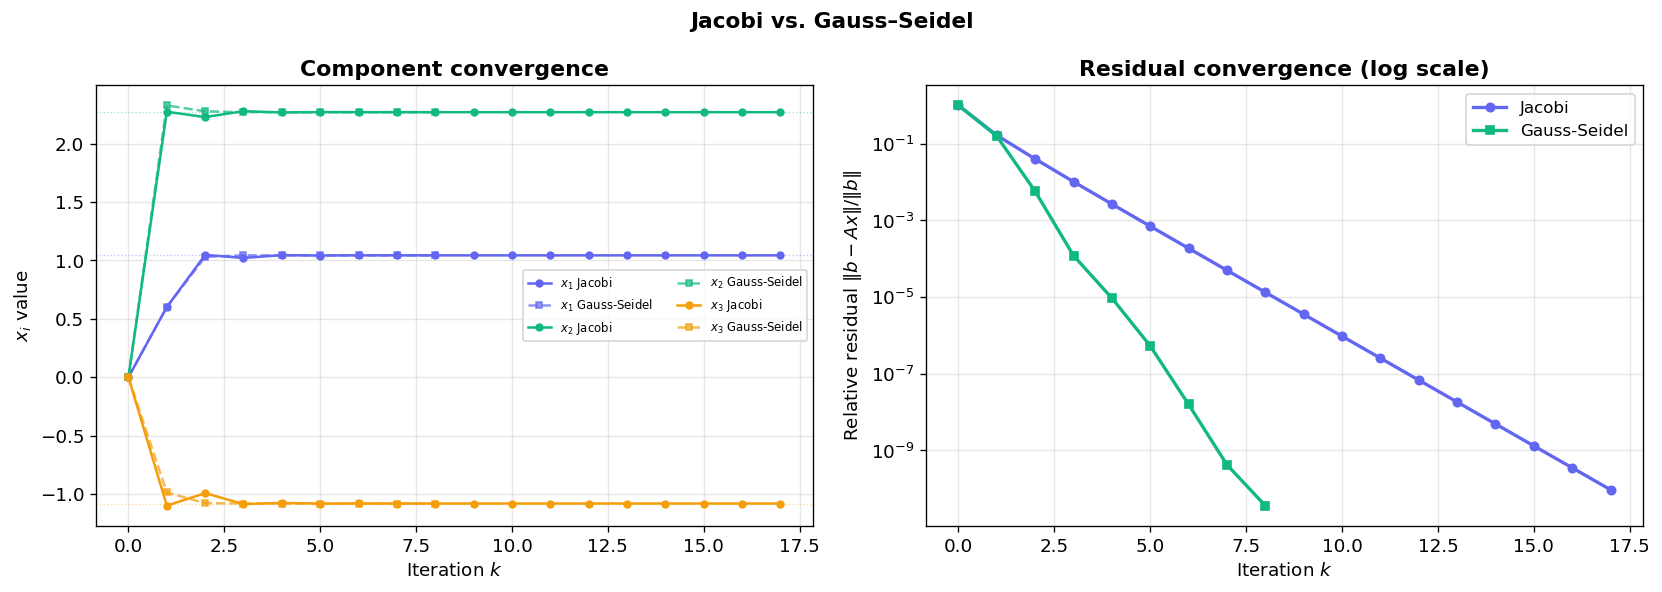

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: component values vs iteration ---
colors = ["#6366f1", "#10b981", "#f59e0b"]
for i, col in enumerate(colors):
    vals_j  = [h["x"][i] for h in h_jacobi]
    vals_gs = [h["x"][i] for h in h_gs]
    ks_j  = [h["k"] for h in h_jacobi]
    ks_gs = [h["k"] for h in h_gs]
    ax1.plot(ks_j,  vals_j,  "o-",  color=col, lw=1.5, markersize=4,
             label=f"$x_{i+1}$ Jacobi")
    ax1.plot(ks_gs, vals_gs, "s--", color=col, lw=1.5, markersize=4,
             alpha=0.7, label=f"$x_{i+1}$ Gauss-Seidel")
    ax1.axhline(x_exact[i], color=col, ls=":", lw=0.8, alpha=0.4)

ax1.set_xlabel("Iteration $k$")
ax1.set_ylabel("$x_i$ value")
ax1.set_title("Component convergence", fontweight="bold")
ax1.legend(fontsize=7, ncol=2)

# --- Right: residual vs iteration ---
ks_j  = [h["k"] for h in h_jacobi]
res_j = [h["residual"] for h in h_jacobi]
ks_gs = [h["k"] for h in h_gs]
res_gs= [h["residual"] for h in h_gs]

ax2.semilogy(ks_j,  res_j,  "o-", color="#6366f1", lw=2, markersize=5,
             label="Jacobi")
ax2.semilogy(ks_gs, res_gs, "s-", color="#10b981", lw=2, markersize=5,
             label="Gauss-Seidel")
ax2.set_xlabel("Iteration $k$")
ax2.set_ylabel("Relative residual $\\|b - Ax\\| / \\|b\\|$")
ax2.set_title("Residual convergence (log scale)", fontweight="bold")
ax2.legend(fontsize=10)

fig.suptitle("Jacobi vs. Gauss–Seidel", fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

Gauss–Seidel typically converges about **twice as fast** as Jacobi
(in terms of iterations) because it uses updated information
immediately.

## 6 — Matrix Splitting Interpretation

Both methods can be understood as **matrix splittings** $A = M - N$,
where the iteration becomes $M\,x^{(k+1)} = N\,x^{(k)} + b$.

| Method | $M$ | $N$ |
|--------|-----|-----|
| Jacobi | $D$ (diagonal) | $-(L + U)$ |
| Gauss–Seidel | $D + L$ (lower triangle) | $-U$ |

The convergence rate depends on the **spectral radius** of the
iteration matrix $G = M^{-1} N$: convergence iff $\rho(G) < 1$.

In [7]:
D = np.diag(np.diag(A))
L = np.tril(A, -1)
U = np.triu(A,  1)

# Jacobi iteration matrix: G_J = D^{-1}(L + U)  (note: minus signs handled)
D_inv = np.linalg.inv(D)
G_jacobi = -D_inv @ (L + U)
rho_jacobi = max(abs(np.linalg.eigvals(G_jacobi)))

# Gauss-Seidel iteration matrix: G_GS = (D + L)^{-1} U  (note: minus signs)
G_gs = -np.linalg.inv(D + L) @ U
rho_gs = max(abs(np.linalg.eigvals(G_gs)))

print(f"Spectral radius (Jacobi):       ρ = {rho_jacobi:.4f}")
print(f"Spectral radius (Gauss-Seidel): ρ = {rho_gs:.4f}")
print()
print(f"Both < 1 → convergence guaranteed ✓")
print(f"Gauss-Seidel's ρ ≈ ρ_Jacobi²: {rho_jacobi**2:.4f} ≈ {rho_gs:.4f}")

Spectral radius (Jacobi):       ρ = 0.2679
Spectral radius (Gauss-Seidel): ρ = 0.0426

Both < 1 → convergence guaranteed ✓
Gauss-Seidel's ρ ≈ ρ_Jacobi²: 0.0718 ≈ 0.0426


## 7 — Effect of Diagonal Dominance

When the diagonal is weak, convergence slows (or fails).

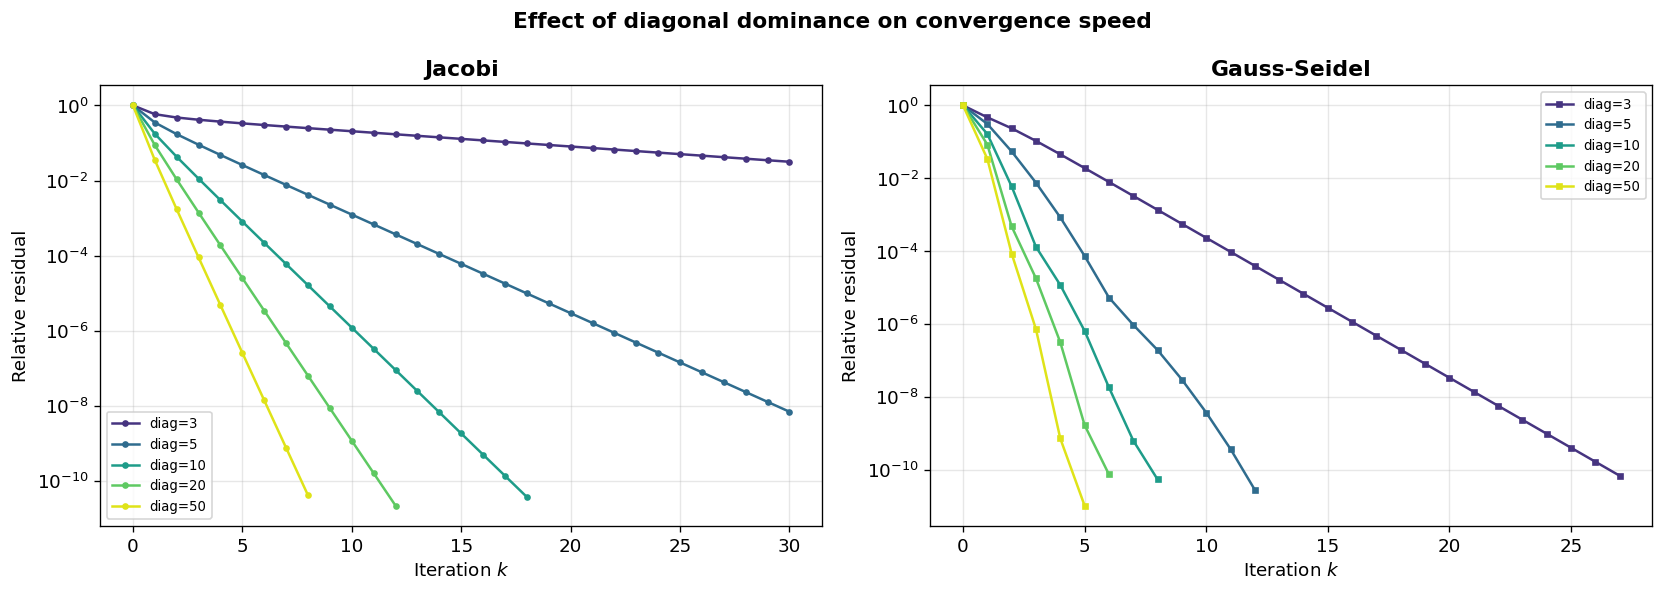

In [8]:
# Parametric study: scale diagonal from weak to strong
scales = [3, 5, 10, 20, 50]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
cmap = plt.cm.viridis(np.linspace(0.15, 0.95, len(scales)))

for s, col in zip(scales, cmap):
    A_test = np.array([[s, -1, 2], [-1, s, -1], [2, -1, s]], dtype=float)
    b_test = np.array([6, 25, -11], dtype=float)

    hj = jacobi(A_test, b_test, np.zeros(3), max_iter=30)
    hg = gauss_seidel(A_test, b_test, np.zeros(3), max_iter=30)

    ks_j = [h["k"] for h in hj]
    res_j = [h["residual"] for h in hj]
    ks_g = [h["k"] for h in hg]
    res_g = [h["residual"] for h in hg]

    ax1.semilogy(ks_j, res_j, "o-", color=col, lw=1.5, markersize=3,
                 label=f"diag={s}")
    ax2.semilogy(ks_g, res_g, "s-", color=col, lw=1.5, markersize=3,
                 label=f"diag={s}")

ax1.set_title("Jacobi", fontweight="bold")
ax2.set_title("Gauss-Seidel", fontweight="bold")
for ax in (ax1, ax2):
    ax.set_xlabel("Iteration $k$")
    ax.set_ylabel("Relative residual")
    ax.legend(fontsize=8)

fig.suptitle("Effect of diagonal dominance on convergence speed",
             fontsize=13, fontweight="bold")
fig.tight_layout()
plt.show()

## 8 — Larger System: 10×10

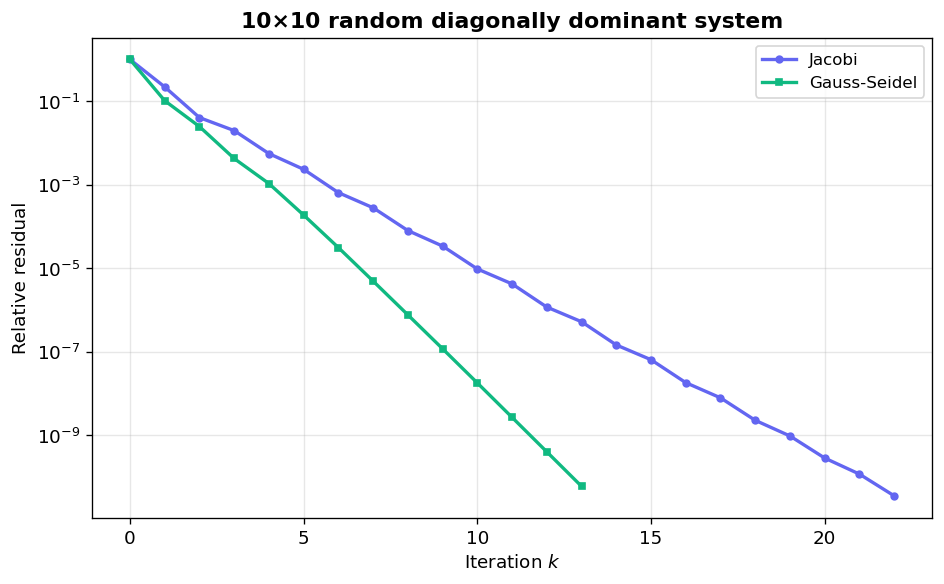

Jacobi:       22 iterations
Gauss-Seidel: 13 iterations
Max error (GS): 1.00e-10


In [9]:
# Generate a random diagonally dominant 10×10 system
np.random.seed(42)
n = 10
A_big = np.random.randn(n, n)
# Make it diagonally dominant
for i in range(n):
    A_big[i, i] = sum(abs(A_big[i, j]) for j in range(n) if j != i) + 2.0

x_true = np.random.randn(n)
b_big = A_big @ x_true

hj = jacobi(A_big, b_big, np.zeros(n), max_iter=100)
hg = gauss_seidel(A_big, b_big, np.zeros(n), max_iter=100)

fig, ax = plt.subplots(figsize=(8, 5))
ax.semilogy([h["k"] for h in hj], [h["residual"] for h in hj],
            "o-", color="#6366f1", lw=2, markersize=4, label="Jacobi")
ax.semilogy([h["k"] for h in hg], [h["residual"] for h in hg],
            "s-", color="#10b981", lw=2, markersize=4, label="Gauss-Seidel")
ax.set_xlabel("Iteration $k$")
ax.set_ylabel("Relative residual")
ax.set_title(f"10×10 random diagonally dominant system", fontweight="bold")
ax.legend(fontsize=10)
fig.tight_layout()
plt.show()

print(f"Jacobi:       {len(hj)-1} iterations")
print(f"Gauss-Seidel: {len(hg)-1} iterations")
print(f"Max error (GS): {np.max(np.abs(hg[-1]['x'] - x_true)):.2e}")

## 9 — Comparison with Direct Solver

In [10]:
# When are iterative methods preferable over direct (e.g. LU)?

sizes = [10, 50, 100, 500]

print(f"{'n':>5}  {'Direct (LU)':>14}  {'Jacobi iters':>14}  {'GS iters':>10}")
print("-" * 50)

for n in sizes:
    np.random.seed(0)
    A_n = np.random.randn(n, n)
    for i in range(n):
        A_n[i, i] = sum(abs(A_n[i, j]) for j in range(n) if j != i) + 2
    x_true_n = np.ones(n)
    b_n = A_n @ x_true_n

    hj = jacobi(A_n, b_n, np.zeros(n), max_iter=200, tol=1e-8)
    hg = gauss_seidel(A_n, b_n, np.zeros(n), max_iter=200, tol=1e-8)

    print(f"{n:>5}  {'O(n³)':>14}  {len(hj)-1:>14}  {len(hg)-1:>10}")

print()
print("For large sparse systems, iterative methods need only O(n) per step.")
print("Direct methods need O(n³) — prohibitive for n > 10,000.")

    n     Direct (LU)    Jacobi iters    GS iters
--------------------------------------------------
   10           O(n³)              19          10
   50           O(n³)              11           8
  100           O(n³)               9           7
  500           O(n³)               7           6

For large sparse systems, iterative methods need only O(n) per step.
Direct methods need O(n³) — prohibitive for n > 10,000.


## 10 — Notes for Students

### Key take-aways

1. **Jacobi** computes all new values from the old iteration —
   each component is independent, making it trivially parallel.
   Gauss–Seidel uses updated values immediately, which is
   inherently sequential but typically converges ~2× faster.

2. **Diagonal dominance** guarantees convergence for both methods.
   The stronger the dominance, the faster the convergence.

3. **Spectral radius** $\rho(G) < 1$ is the formal convergence
   criterion. For symmetric positive definite matrices,
   Gauss–Seidel always converges.

4. **Iterative vs. direct** — For small dense systems, LU
   factorisation is faster. Iterative methods shine for
   **large sparse** systems (FEM, CFD, image processing)
   where each iteration costs $O(\text{nnz})$ instead of $O(n^3)$.

5. **SOR** (Successive Over-Relaxation) is a generalisation of
   Gauss–Seidel with a relaxation parameter $\omega$ that can
   further accelerate convergence.

### Exercises

1. Implement **SOR** (Successive Over-Relaxation):
   $x_i^{\text{new}} = (1-\omega)\,x_i^{(k)} + \omega\,x_i^{\text{GS}}$.
   Find the optimal $\omega$ for the test system.

2. Construct a $3 \times 3$ matrix that is **not** diagonally
   dominant. Show that Jacobi diverges but verify convergence
   still holds if $\rho(G) < 1$.

3. Count the number of **floating-point operations** per iteration
   for an $n \times n$ dense system. Compare with the $O(n^3)$
   cost of Gaussian elimination.

4. Modify the Gauss–Seidel implementation to handle a **sparse**
   matrix (use `scipy.sparse`). Time it against the dense version
   for $n = 1000$.

5. Apply both methods to a 1D Poisson equation
   ($-u'' = f$ on $[0,1]$ with $u(0) = u(1) = 0$,
   discretised with finite differences). Plot the solution
   at iterations $k = 1, 5, 20, 100$.